# Video 9: LLMs for Scientific Literature Mining in Drug Discovery

**AI for Drug Discovery series | DigitalSreeni**

---

In the previous videos we computationally generated and scored candidate EGFR inhibitor molecules. The best leads from Video 7b were CHEMBL382797, CHEMBL13462, and CHEMBL112582 (all scoring 7/10 on ADMET). Video 8 then used scaffold decoration and a GPT-based generative model (SelfiesGPT) to produce new molecules, with the best generated compound scoring 10/10.

Before any of these molecules go near a lab, a medicinal chemist would go back to the published literature and ask three questions:

1. What resistance mechanisms have emerged against existing EGFR inhibitors, and will our new molecules face the same problems?
2. What is the clinical history of the quinazoline scaffold that our leads are built on?
3. Given everything the literature says, what therapeutic gap does a next-generation EGFR inhibitor still need to fill?

Answering these questions manually means reading hundreds of papers over several days. In this notebook we use GPT-4o to do it in minutes: fetch real PubMed abstracts, extract structured information from each one, aggregate across the full set, and synthesize a research briefing that connects directly back to our candidate molecules.

**What this notebook covers:**
- Live PubMed search and abstract fetching via the NCBI Entrez API
- LLM-powered structured extraction (target, drugs, mutations, mechanisms, study type, key finding)
- Aggregation and visualization of resistance mutations and drug mentions across the literature
- A second targeted search focused on the quinazoline scaffold class of our lead compounds
- A synthesis query that produces a structured research briefing saved to disk

## Cell 1: Installs, Imports, and Configuration

We install `openai` for LLM calls and `biopython` for PubMed access via the NCBI Entrez API. The `.env` file on Google Drive holds our API keys so they never appear in the notebook. We also set DejaVu Sans as the plot font, since Arial is not available in the Colab Linux environment, and create a `results/` directory to hold all outputs from this notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 1 -- installs, imports, API keys, configuration

!pip install openai biopython -q

import os
import re
import time
import json
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from Bio import Entrez
from openai import OpenAI

# Suppress miscellaneous warnings
warnings.filterwarnings('ignore')

# Results directory -- all outputs from this notebook go here

RESULTS_DIR = Path('/content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video9_llm/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')

# DejaVu Sans is available in the Colab Linux environment; Arial is not
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load API keys from .env file on Google Drive
ENV_PATH = '/content/drive/MyDrive/ColabNotebooks/llm_for_scientists/llm_keys/.env'

with open(ENV_PATH) as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            key, value = line.split('=', 1)
            os.environ[key.strip()] = value.strip()

OPENAI_API_KEY    = os.environ.get('OPENAI_API_KEY')
ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY')

print(f'OpenAI key loaded:    {OPENAI_API_KEY[:8]}...'    if OPENAI_API_KEY    else 'OpenAI key NOT found')
print(f'Anthropic key loaded: {ANTHROPIC_API_KEY[:8]}...' if ANTHROPIC_API_KEY else 'Anthropic key NOT found')

# NCBI Entrez requires an email address so they can contact you if needed
Entrez.email = 'your.email@example.com'  # replace with your email

# OpenAI client and model selection
client    = OpenAI(api_key=OPENAI_API_KEY)
LLM_MODEL = 'gpt-4o'

print(f'\nLLM model: {LLM_MODEL}')
print('Configuration complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 41.0 MB/s eta 0:00:00
Results will be saved to: /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video9_llm/results
OpenAI key loaded:    sk-proj-...
Anthropic key loaded: sk-ant-a...

LLM model: gpt-4o
Configuration complete.


## Cell 2: Shared Utility Functions

These four functions are used throughout the notebook.

- `strip_markdown_fences` and `parse_llm_json` handle a consistent behavior of GPT-4o: even at temperature 0 it wraps JSON output in markdown code fences. We strip those before parsing.
- `pubmed_search` runs a keyword query against PubMed and returns a list of PMIDs.
- `pubmed_fetch_abstracts` fetches the full records for those PMIDs in XML format and parses out the fields we need: PMID, title, journal, year, and abstract text. It handles structured abstracts (those with Background / Methods / Results sections) by joining all parts into one string.
- `format_article_for_llm` formats a parsed article dict into the prompt string we send to the LLM.

In [ ]:
# Cell 2 -- shared utility functions used throughout the notebook

def strip_markdown_fences(text):
    """Remove markdown code fences that GPT-4o wraps around JSON responses."""
    text = text.strip()
    text = re.sub(r'^```[a-zA-Z]*\n?', '', text)
    text = re.sub(r'\n?```$', '', text)
    return text.strip()


def parse_llm_json(raw_text):
    """Strip markdown fences and parse JSON. Returns dict or None on failure."""
    cleaned = strip_markdown_fences(raw_text)
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        print(f'JSON parsing failed: {e}')
        return None


def pubmed_search(query, max_results=20):
    """Search PubMed and return a list of PMIDs sorted by relevance."""
    handle = Entrez.esearch(db='pubmed', term=query, retmax=max_results, sort='relevance')
    record = Entrez.read(handle)
    handle.close()
    return record['IdList']


def pubmed_fetch_abstracts(pmids):
    """Fetch and parse PubMed abstracts for a list of PMIDs. Returns list of dicts."""
    time.sleep(0.5)  # pause briefly to be polite to NCBI servers
    handle  = Entrez.efetch(db='pubmed', id=','.join(pmids), rettype='medline', retmode='xml')
    xml_data = handle.read()
    handle.close()

    root     = ET.fromstring(xml_data)
    articles = []

    for article_node in root.findall('.//PubmedArticle'):
        fields = {}

        pmid_node         = article_node.find('.//PMID')
        fields['pmid']    = pmid_node.text if pmid_node is not None else 'N/A'

        title_node        = article_node.find('.//ArticleTitle')
        fields['title']   = title_node.text if title_node is not None else 'N/A'

        journal_node      = article_node.find('.//Journal/Title')
        fields['journal'] = journal_node.text if journal_node is not None else 'N/A'

        year_node = article_node.find('.//PubDate/Year')
        if year_node is None:
            year_node = article_node.find('.//PubDate/MedlineDate')
        fields['year'] = year_node.text[:4] if year_node is not None else 'N/A'

        # Handle structured abstracts (Background / Methods / Results / Conclusions)
        abstract_nodes = article_node.findall('.//AbstractText')
        if abstract_nodes:
            parts = []
            for node in abstract_nodes:
                label = node.get('Label')
                text  = node.text or ''
                parts.append(f'{label}: {text}' if label else text)
            fields['abstract'] = ' '.join(parts)
        else:
            fields['abstract'] = 'No abstract available'

        articles.append(fields)

    return articles


def format_article_for_llm(article):
    """Format a parsed article dict into a prompt string for the LLM."""
    return (
        f"Title: {article['title']}\n"
        f"Journal: {article['journal']} ({article['year']})\n"
        f"PMID: {article['pmid']}\n\n"
        f"Abstract:\n{article['abstract']}"
    )


print('Utility functions defined.')

Utility functions defined.


## Section 1: Resistance Landscape

The first question a researcher asks before advancing a new EGFR inhibitor is: what resistance mechanisms have already defeated previous drugs in this class, and will our molecules face the same problems?

EGFR-targeted therapy has gone through three generations. First-generation inhibitors (erlotinib, gefitinib) were defeated primarily by the T790M gatekeeper mutation. Third-generation osimertinib was designed to overcome T790M, but resistance emerged again through new mechanisms: the C797S mutation, MET amplification, histological transformation to small cell lung cancer, and bypass signaling through other receptor tyrosine kinases.

We search PubMed for papers on EGFR inhibitor resistance and use GPT-4o to extract structured information from each abstract: which drugs are mentioned, which resistance mutations appear, which bypass mechanisms are described, and what the key finding is. Aggregating across 20 papers gives us a quantitative picture of which resistance mechanisms dominate the literature.

In [ ]:
# Cell 3 -- PubMed search: EGFR resistance landscape
# We fetch 20 papers on EGFR inhibitor resistance in NSCLC.

RESISTANCE_QUERY = 'EGFR tyrosine kinase inhibitor resistance mechanism non-small cell lung cancer'
MAX_RESISTANCE   = 20

print(f'Search query: {RESISTANCE_QUERY}')
print(f'Fetching up to {MAX_RESISTANCE} abstracts from PubMed...\n')

resistance_pmids    = pubmed_search(RESISTANCE_QUERY, max_results=MAX_RESISTANCE)
resistance_articles = pubmed_fetch_abstracts(resistance_pmids)

print(f'Abstracts fetched and parsed: {len(resistance_articles)}\n')
for i, a in enumerate(resistance_articles):
    print(f"  {i+1:>2}. [{a['year']}] {a['title'][:90]}...")

Search query: EGFR tyrosine kinase inhibitor resistance mechanism non-small cell lung cancer
Fetching up to 20 abstracts from PubMed...

Abstracts fetched and parsed: 20

   1. [2019] Resistance mechanisms to osimertinib in EGFR-mutated non-small cell lung cancer....
   2. [2022] Therapeutic strategies for EGFR-mutated non-small cell lung cancer patients with osimertin...
   3. [2024] Overcoming tyrosine kinase inhibitor resistance in lung cancer brain metastasis with CTLA4...
   4. [2021] Mechanisms and management of 3rd‑generation EGFR‑TKI resistance in advanced non‑small cell...
   5. [2023] Tackling Osimertinib Resistance in EGFR-Mutant Non-Small Cell Lung Cancer....
   6. [2021] Overcoming therapy resistance in EGFR-mutant lung cancer....
   7. [2004] Activating mutations in the epidermal growth factor receptor underlying responsiveness of ...
   8. [2022] Efficacy and Safety of Patritumab Deruxtecan (HER3-DXd) in EGFR Inhibitor-Resistant, ...
   9. [2022] EGFR-Mutated Non-Small C

## Cell 4: LLM Structured Extraction over Resistance Papers

We now send each abstract to GPT-4o with a system prompt that defines exactly what fields we want extracted. The model returns a JSON object for each paper. We use temperature 0 to minimize variability across calls and pause one second between calls to stay within OpenAI rate limits.

The extraction includes a `resistance_mechanisms` field that goes beyond point mutations and captures higher-level mechanisms like MET amplification, bypass signaling, and histological transformation. These are the mechanisms that a structural change to a small molecule alone cannot overcome, and knowing about them is important context when deciding which leads to prioritize.

In [ ]:
# Cell 4 -- LLM structured extraction over all resistance papers
# Each abstract is sent to GPT-4o. Results are collected into a DataFrame and saved to CSV.

SYSTEM_PROMPT_EXTRACTION = """You are a biomedical literature analyst. Given a PubMed abstract, extract the following fields and return them as a valid JSON object with no additional text or formatting.

Fields to extract:
- target: the primary molecular target (e.g. EGFR, KRAS). Return 'N/A' if not mentioned.
- drug_names: list of drug or compound names mentioned. Return empty list if none.
- resistance_mutations: list of resistance mutations mentioned (e.g. T790M, C797S). Return empty list if none.
- resistance_mechanisms: list of resistance mechanisms beyond point mutations (e.g. MET amplification, EMT, bypass signaling, histological transformation). Return empty list if none.
- study_type: one of [clinical, preclinical, review, computational, unknown]
- key_finding: one sentence summarizing the main finding or conclusion of the paper.
- relevance_to_drug_discovery: one sentence on why this paper is relevant to EGFR-targeted drug discovery."""

extracted_records = []

for i, article in enumerate(resistance_articles):
    print(f"Processing {i+1}/{len(resistance_articles)}: PMID {article['pmid']}...", end=' ')

    if article['abstract'] == 'No abstract available':
        print('skipped (no abstract)')
        continue

    response = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT_EXTRACTION},
            {'role': 'user',   'content': format_article_for_llm(article)}
        ],
        temperature=0.0,
        max_tokens=600
    )

    raw    = response.choices[0].message.content
    parsed = parse_llm_json(raw)

    if parsed:
        parsed['pmid']    = article['pmid']
        parsed['title']   = article['title']
        parsed['journal'] = article['journal']
        parsed['year']    = article['year']
        extracted_records.append(parsed)
        print('done')
    else:
        print('parse failed')

    time.sleep(1.0)  # pause between calls to respect OpenAI rate limits

df_resistance = pd.DataFrame(extracted_records)
df_resistance.to_csv(RESULTS_DIR / 'resistance_landscape.csv', index=False)
print(f'\nExtraction complete. {len(df_resistance)} records saved to {RESULTS_DIR}/resistance_landscape.csv')

print(df_resistance[['pmid', 'year', 'study_type', 'target']].to_string(index=False))

Processing 1/20: PMID 31564718... done
Processing 2/20: PMID 36482474... done
Processing 3/20: PMID 39423817... done
Processing 4/20: PMID 34558640... done
Processing 5/20: PMID 37093192... done
Processing 6/20: PMID 35122001... done
Processing 7/20: PMID 15118073... done
Processing 8/20: PMID 34548309... done
Processing 9/20: PMID 35742933... done
Processing 10/20: PMID 25923549... done
Processing 11/20: PMID 40505315... done
Processing 12/20: PMID 38760351... done
Processing 13/20: PMID 37279591... done
Processing 14/20: PMID 36849494... done
Processing 15/20: PMID 41150710... done
Processing 16/20: PMID 38382773... done
Processing 17/20: PMID 39150541... done
Processing 18/20: PMID 35303882... done
Processing 19/20: PMID 37061993... done
Processing 20/20: PMID 37060646... done

Extraction complete. 20 records saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video9_llm/results/resistance_landscape.csv
    pmid year  study_type target
31564718 2019      review   EG

## Cell 5: Resistance Mutation Frequency Chart

We aggregate all resistance mutations mentioned across the 20 papers and plot their frequency. This gives a quantitative answer to the question: which mutations appear most often in the EGFR resistance literature?

We expect T790M to dominate, since it was the primary resistance mechanism to first- and second-generation EGFR inhibitors. C797S, which confers resistance to osimertinib, should appear in more recent papers. Other mutations like L718Q, G796D, and exon 20 insertions may also appear depending on which papers were returned.

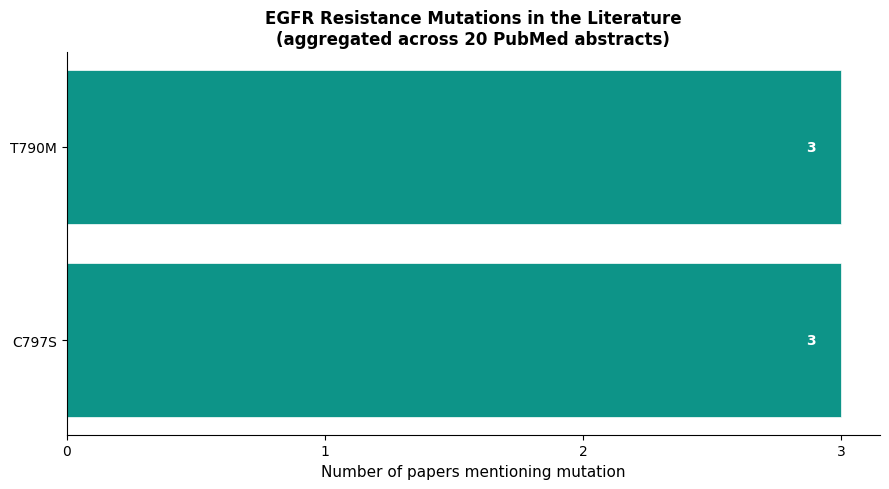


Chart saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video9_llm/results/resistance_mutations.png

Top mutations: {'T790M': 3, 'C797S': 3}


In [ ]:
# Cell 5 -- resistance mutation frequency chart
# We flatten all resistance_mutations lists across papers, count occurrences, and plot.

all_mutations = []
for record in extracted_records:
    mutations = record.get('resistance_mutations', [])
    if isinstance(mutations, list):
        all_mutations.extend(mutations)

mutation_counts = Counter(all_mutations)
top_mutations   = mutation_counts.most_common(10)

if top_mutations:
    labels, counts = zip(*top_mutations)

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(labels[::-1], counts[::-1], color='#0D9488', edgecolor='white', linewidth=0.5)

    ax.set_xlabel('Number of papers mentioning mutation', fontsize=11)
    ax.set_title('EGFR Resistance Mutations in the Literature\n(aggregated across 20 PubMed abstracts)', fontsize=12, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Add count labels inside bars
    for bar, count in zip(bars, counts[::-1]):
        ax.text(bar.get_width() - 0.1, bar.get_y() + bar.get_height() / 2,
                str(count), va='center', ha='right', color='white', fontsize=10, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'resistance_mutations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nChart saved to {RESULTS_DIR}/resistance_mutations.png')
    print(f'\nTop mutations: {dict(top_mutations)}')
else:
    print('No resistance mutations found in extracted records.')

## Cell 6: Drug Landscape Chart

We apply the same aggregation to drug names. This shows which EGFR inhibitors appear most frequently across the resistance literature, giving us a quick map of the competitive landscape our lead compounds would enter.

Osimertinib dominates third-generation EGFR inhibitor literature. Earlier drugs like erlotinib and gefitinib appear frequently in historical context. Newer agents like amivantamab (an EGFR/MET bispecific antibody) and lazertinib appear in more recent papers on combination strategies.

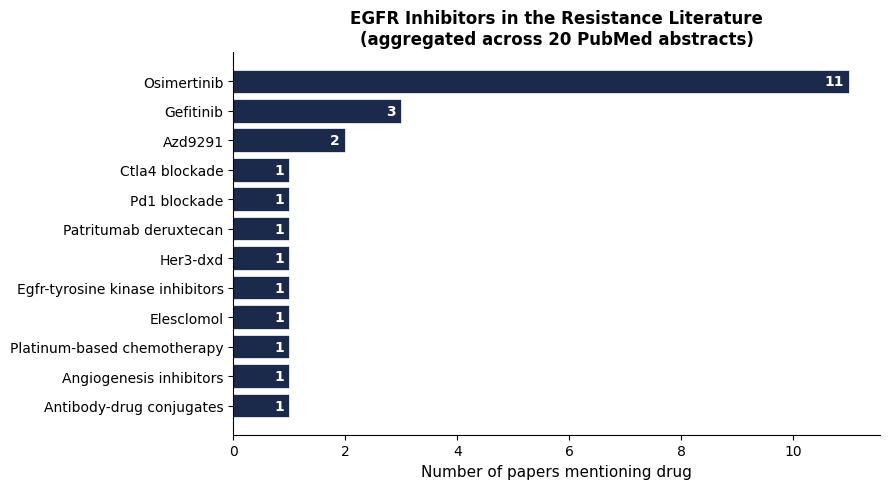


Chart saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video9_llm/results/drug_landscape.png

Chart saved to results/drug_landscape.png


In [ ]:
# Cell 6 -- drug landscape chart
# We flatten all drug_names lists across papers, count occurrences, and plot.

all_drugs = []
for record in extracted_records:
    drugs = record.get('drug_names', [])
    if isinstance(drugs, list):
        # Normalize to lowercase for counting, keep original case for display
        all_drugs.extend([d.lower().strip() for d in drugs])

drug_counts = Counter(all_drugs)
# Remove very generic terms that are not drug names
for generic in ['tki', 'tkis', 'chemotherapy', 'inhibitor', 'antibody']:
    drug_counts.pop(generic, None)

top_drugs = drug_counts.most_common(12)

if top_drugs:
    labels, counts = zip(*top_drugs)
    labels = [d.capitalize() for d in labels]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(labels[::-1], counts[::-1], color='#1B2A4A', edgecolor='white', linewidth=0.5)

    ax.set_xlabel('Number of papers mentioning drug', fontsize=11)
    ax.set_title('EGFR Inhibitors in the Resistance Literature\n(aggregated across 20 PubMed abstracts)', fontsize=12, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    for bar, count in zip(bars, counts[::-1]):
        ax.text(bar.get_width() - 0.1, bar.get_y() + bar.get_height() / 2,
                str(count), va='center', ha='right', color='white', fontsize=10, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'drug_landscape.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nChart saved to {RESULTS_DIR}/drug_landscape.png')
    print(f'\nChart saved to results/drug_landscape.png')
else:
    print('No drug names found in extracted records.')

## Section 2: Scaffold-Specific Literature Search

Our lead compounds from Video 7b belong to the quinazoline scaffold class, which is the core structural motif of erlotinib, gefitinib, lapatinib, and osimertinib. This is one of the most extensively studied scaffolds in oncology.

Before advancing a new quinazoline-based EGFR inhibitor, a medicinal chemist would ask: what is the clinical history of this scaffold? Which compounds in this class have entered human trials? What selectivity and toxicity patterns have been observed? What structural modifications have been tried to overcome resistance?

We run a second targeted PubMed search focused specifically on the quinazoline scaffold in EGFR-targeted therapy and apply the same LLM extraction pipeline to the results.

In [ ]:
# Cell 7 -- PubMed search: quinazoline scaffold in EGFR-targeted therapy
# This is a more focused search connecting directly to the structural class of our lead compounds.

SCAFFOLD_QUERY = 'quinazoline EGFR inhibitor medicinal chemistry structure activity'
MAX_SCAFFOLD   = 10

print(f'Search query: {SCAFFOLD_QUERY}')
print(f'Fetching up to {MAX_SCAFFOLD} abstracts from PubMed...\n')

scaffold_pmids    = pubmed_search(SCAFFOLD_QUERY, max_results=MAX_SCAFFOLD)
scaffold_articles = pubmed_fetch_abstracts(scaffold_pmids)

print(f'Abstracts fetched and parsed: {len(scaffold_articles)}\n')
for i, a in enumerate(scaffold_articles):
    print(f"  {i+1:>2}. [{a['year']}] {a['title'][:90]}...")

Search query: quinazoline EGFR inhibitor medicinal chemistry structure activity
Fetching up to 10 abstracts from PubMed...

Abstracts fetched and parsed: 10

   1. [2023] Structure-Activity Relationship Studies Based on Quinazoline Derivatives as EGFR Kinase In...
   2. [2025] Targeting both wild-type EGFR and its drug-resistant mutants with erlotinib-aptamer conjug...
   3. [2015] Structure-activity study of quinazoline derivatives leading to the discovery of potent EGF...
   4. [2022] An appraisal of anticancer activity with structure-activity relationship of quinazoline an...
   5. [2020] Structure-activity relationship study of novel quinazoline-based 1,6-naphthyridinones as M...
   6. [2026] Medicinal chemistry perspective on quinazoline derivatives: Sustainable synthetic routes, ...
   7. [2022] Macrocyclization of Quinazoline-Based EGFR Inhibitors Leads to Exclusive Mutant Selectivit...
   8. [2024] Novel 2-[thio]acetamide linked quinazoline/1,2,4-triazole/chalcone hybrids: Desi

## Cell 8: LLM Extraction over Scaffold Papers

We use the same extraction pipeline on the scaffold-focused papers. For this set we add one extra field: `clinical_stage`, which asks the model to report whether the paper describes a compound at the preclinical, Phase I, Phase II, Phase III, or approved stage. This helps us understand where the scaffold class sits in the development landscape and what structural features correlate with clinical success.

In [ ]:
# Cell 8 -- LLM extraction over scaffold-focused papers
# Same pipeline as Cell 4, with an additional clinical_stage field.

SYSTEM_PROMPT_SCAFFOLD = """You are a biomedical literature analyst. Given a PubMed abstract, extract the following fields and return them as a valid JSON object with no additional text or formatting.

Fields to extract:
- target: the primary molecular target. Return 'N/A' if not mentioned.
- drug_names: list of drug or compound names mentioned. Return empty list if none.
- scaffold_class: the core chemical scaffold described (e.g. quinazoline, pyrrolopyrimidine, aminopyrimidine). Return 'N/A' if not mentioned.
- clinical_stage: the most advanced clinical stage mentioned for any compound in this paper. One of [preclinical, phase_1, phase_2, phase_3, approved, unknown].
- selectivity_notes: one sentence on any selectivity or off-target observations mentioned. Return 'Not mentioned' if absent.
- study_type: one of [clinical, preclinical, review, computational, unknown]
- key_finding: one sentence summarizing the main finding or conclusion of the paper."""

scaffold_records = []

for i, article in enumerate(scaffold_articles):
    print(f"Processing {i+1}/{len(scaffold_articles)}: PMID {article['pmid']}...", end=' ')

    if article['abstract'] == 'No abstract available':
        print('skipped (no abstract)')
        continue

    response = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT_SCAFFOLD},
            {'role': 'user',   'content': format_article_for_llm(article)}
        ],
        temperature=0.0,
        max_tokens=500
    )

    raw    = response.choices[0].message.content
    parsed = parse_llm_json(raw)

    if parsed:
        parsed['pmid']    = article['pmid']
        parsed['title']   = article['title']
        parsed['journal'] = article['journal']
        parsed['year']    = article['year']
        scaffold_records.append(parsed)
        print('done')
    else:
        print('parse failed')

    time.sleep(1.0)

df_scaffold = pd.DataFrame(scaffold_records)

df_scaffold.to_csv(RESULTS_DIR / 'scaffold_literature.csv', index=False)
print(f'\nExtraction complete. {len(df_scaffold)} records saved to {RESULTS_DIR}/scaffold_literature.csv')

print(df_scaffold[['pmid', 'year', 'clinical_stage', 'scaffold_class']].to_string(index=False))

Processing 1/10: PMID 37111291... done
Processing 2/10: PMID 40554308... done
Processing 3/10: PMID 26310890... done
Processing 4/10: PMID 35297084... done
Processing 5/10: PMID 32898795... done
Processing 6/10: PMID 41478011... done
Processing 7/10: PMID 36384036... done
Processing 8/10: PMID 38593298... done
Processing 9/10: PMID 34074193... done
Processing 10/10: PMID 38584547... done

Extraction complete. 10 records saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video9_llm/results/scaffold_literature.csv
    pmid year clinical_stage                scaffold_class
37111291 2023       approved                   quinazoline
40554308 2025    preclinical                           N/A
26310890 2015    preclinical                   quinazoline
35297084 2022       approved quinazoline and quinazolinone
32898795 2020    preclinical                   quinazoline
41478011 2026        unknown                   quinazoline
36384036 2022    preclinical                   quin

## Cell 9: Scaffold Papers Summary Table

We display the key findings from the scaffold-focused papers as a clean summary table. This is the kind of output a researcher would share in a lab meeting: a concise one-line summary of each paper, sorted by year, with the clinical stage and key finding in view.

In [ ]:
# Cell 9 -- scaffold papers summary table

if not df_scaffold.empty:
    display_cols = ['pmid', 'year', 'clinical_stage', 'scaffold_class', 'key_finding']
    available    = [c for c in display_cols if c in df_scaffold.columns]
    summary      = df_scaffold[available].sort_values('year', ascending=False)

    pd.set_option('display.max_colwidth', 100)
    print('Scaffold literature summary (sorted by year):\n')
    print(summary.to_string(index=False))
else:
    print('No scaffold records to display.')

Scaffold literature summary (sorted by year):

    pmid year clinical_stage                scaffold_class                                                                                                                                                                                                                                                     key_finding
41478011 2026        unknown                   quinazoline                                                                                                         Quinazoline derivatives have versatile biological activity and can modulate multiple oncogenic pathways, including strong inhibition of EGFR and VEGFR.
40554308 2025    preclinical                           N/A                                                                                                The erlotinib-aptamer conjugate LY-dE#5 is an efficient pan-EGFR degrader that holds translational potential for overcoming drug-resistance issues in EGFR-TKIs.
38593298

## Section 3: Synthesis Query

We now use the LLM in a different way. Instead of extracting information from individual abstracts, we aggregate the key findings from both searches and ask the model to synthesize across them.

The synthesis prompt asks one question: given everything the literature says about EGFR resistance mechanisms and the quinazoline scaffold class, what therapeutic gap does a next-generation EGFR inhibitor still need to fill?

This is the question that connects the literature mining exercise back to our computational leads. The answer frames the scientific rationale for advancing any of our candidate molecules into experimental validation.

In [ ]:
# Cell 10 -- synthesis query over aggregated findings
# We compile key findings from both searches and ask the LLM to synthesize across them.

# Compile key findings from resistance papers
resistance_findings = []
for record in extracted_records:
    kf = record.get('key_finding', '').strip()
    if kf:
        resistance_findings.append(f"- {kf}")

# Compile key findings from scaffold papers
scaffold_findings = []
for record in scaffold_records:
    kf = record.get('key_finding', '').strip()
    if kf:
        scaffold_findings.append(f"- {kf}")

resistance_block = '\n'.join(resistance_findings)
scaffold_block   = '\n'.join(scaffold_findings)

SYNTHESIS_PROMPT = f"""You are a senior medicinal chemist advising a drug discovery team working on next-generation EGFR inhibitors for non-small cell lung cancer.

Below are key findings extracted from two sets of recent PubMed papers.

SET 1 -- EGFR resistance landscape (20 papers):
{resistance_block}

SET 2 -- Quinazoline scaffold clinical literature (10 papers):
{scaffold_block}

Based on these findings, write a structured research briefing with the following sections:
1. Key resistance mechanisms a new EGFR inhibitor must address
2. Strengths and limitations of the quinazoline scaffold class
3. The therapeutic gap that remains open for a next-generation molecule
4. Two or three specific design criteria a new EGFR inhibitor should meet based on this literature

Write in clear, concise scientific prose. Each section should be 3 to 5 sentences. Do not use bullet points inside sections."""

print('Sending synthesis query to GPT-4o...')
print(f'Input: {len(resistance_findings)} resistance findings + {len(scaffold_findings)} scaffold findings\n')

synthesis_response = client.chat.completions.create(
    model=LLM_MODEL,
    messages=[
        {'role': 'user', 'content': SYNTHESIS_PROMPT}
    ],
    temperature=0.2,
    max_tokens=1000
)

synthesis_text = synthesis_response.choices[0].message.content.strip()

print('=== RESEARCH BRIEFING: NEXT-GENERATION EGFR INHIBITORS ===')
print(synthesis_text)

Sending synthesis query to GPT-4o...
Input: 20 resistance findings + 10 scaffold findings

=== RESEARCH BRIEFING: NEXT-GENERATION EGFR INHIBITORS ===
**1. Key resistance mechanisms a new EGFR inhibitor must address**

A new EGFR inhibitor must address several key resistance mechanisms that have been identified in patients with EGFR-mutated non-small cell lung cancer (NSCLC). These include MET amplification and EGFR C797S mutations, which are frequent causes of resistance to first-line osimertinib. Additionally, resistance can arise from alterations in signaling pathways, such as the PI3K-AKT pathway activated by ZDHHC11-mediated palmitoylation of AXL, and metabolic reprogramming involving the IGF2BP3-COX6B2 axis. The inhibitor should also consider overcoming adaptive resistance mechanisms linked to cholesterol accumulation and NCOA4 elevation, which contribute to the persistence of cancer cells despite treatment.

**2. Strengths and limitations of the quinazoline scaffold class**

The 

## Cell 11: Save Research Briefing to Disk

We save the full research briefing as a plain text file in the `results/` directory. This is the artifact a researcher would take into a lab meeting: a concise, literature-grounded summary of the scientific rationale for advancing their computational leads, produced in minutes rather than days.

In [ ]:
# Cell 11 -- save the full research briefing to disk

briefing_path = RESULTS_DIR / 'research_briefing.txt'

briefing_header = (
    'EGFR INHIBITOR DRUG DISCOVERY -- LITERATURE MINING BRIEFING\n'
    'Generated by Video 9 notebook (AI for Drug Discovery series)\n'
    f'Sources: {len(extracted_records)} resistance papers + {len(scaffold_records)} scaffold papers\n'
    + '=' * 65 + '\n\n'
)

briefing_path.write_text(briefing_header + synthesis_text + '\n', encoding='utf-8')

print(f'Research briefing saved to {briefing_path}')
print(f'File size: {briefing_path.stat().st_size} bytes')
print('\nOutputs in results/:')
for f in sorted(RESULTS_DIR.iterdir()):
    print(f'  {f.name}')

Research briefing saved to /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video9_llm/results/research_briefing.txt
File size: 2802 bytes

Outputs in results/:
  drug_landscape.png
  research_briefing.txt
  resistance_landscape.csv
  resistance_mutations.png
  scaffold_literature.csv


## Summary

In this notebook we demonstrated a complete LLM-powered literature mining pipeline for drug discovery.

Starting from two keyword searches against PubMed, we fetched 30 real abstracts, extracted structured information from each one using GPT-4o, aggregated resistance mutations and drug mentions across the full corpus, and synthesized a research briefing connecting the literature directly to our computational lead compounds.

The same pipeline applies to any target, scaffold, or therapeutic area. The only things that change are the search queries and the fields in the extraction prompt.

**In the next video** we will take the best candidate molecules from our computational pipeline into experimental design: how to prioritize compounds for synthesis, what assays to run first, and how to build a structure-activity relationship (SAR) hypothesis from the data we have generated across this series.